# Qwen3.5-9B on MMMU-Pro — Visual-Premise Diversity vs Correctness (v6, truncation removed)

**Experiment.** 24 MMMU-Pro questions (one per subject, all baseline *failures*). The model emits a single **visual premise** (one fact read from the image), **thinking ON**, **4096-token cap**, across 5 top_p × 16 samples.

**This notebook uses the CLEAN set only:** the 232/1920 samples that hit the 4096-token cap (`finish_reason='length'`) are **removed everywhere**. What remains: **1688 samples**, mean **14.1 per (example, top_p) cell** (range 4–16; 5 cells < 8).

A *cell* = one (example, top_p) pair → **120 cells**. **Vendi** = effective # of distinct premises; **frac_correct** = fraction judged correct against the image.

**Runtime → Run all.** Data embedded below; no uploads.


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 120

# ---- embedded CLEAN per-cell data (120 cells, truncated samples removed;
#      diversity embedded on the extracted premise, correctness judged on it too) ----
DATA_JSON = r"""[{"id": "test_Accounting_55", "subject": "Accounting", "top_p": 0.5, "n": 16, "vendi": 1.3921, "cos": 0.0929, "fc": 1.0, "tokens": 1353.4}, {"id": "test_Accounting_55", "subject": "Accounting", "top_p": 0.7, "n": 16, "vendi": 2.209, "cos": 0.2477, "fc": 1.0, "tokens": 1541.5}, {"id": "test_Accounting_55", "subject": "Accounting", "top_p": 0.9, "n": 16, "vendi": 2.9191, "cos": 0.319, "fc": 1.0, "tokens": 1719.1}, {"id": "test_Accounting_55", "subject": "Accounting", "top_p": 0.95, "n": 15, "vendi": 2.4763, "cos": 0.3031, "fc": 1.0, "tokens": 1562.5}, {"id": "test_Accounting_55", "subject": "Accounting", "top_p": 1.0, "n": 15, "vendi": 2.8351, "cos": 0.3405, "fc": 1.0, "tokens": 1860.2}, {"id": "test_Agriculture_19", "subject": "Agriculture", "top_p": 0.5, "n": 16, "vendi": 1.7129, "cos": 0.1254, "fc": 0.875, "tokens": 882.2}, {"id": "test_Agriculture_19", "subject": "Agriculture", "top_p": 0.7, "n": 16, "vendi": 1.5233, "cos": 0.0951, "fc": 1.0, "tokens": 723.1}, {"id": "test_Agriculture_19", "subject": "Agriculture", "top_p": 0.9, "n": 16, "vendi": 1.7161, "cos": 0.1328, "fc": 0.9375, "tokens": 1093.8}, {"id": "test_Agriculture_19", "subject": "Agriculture", "top_p": 0.95, "n": 16, "vendi": 1.8485, "cos": 0.1361, "fc": 0.875, "tokens": 910.8}, {"id": "test_Agriculture_19", "subject": "Agriculture", "top_p": 1.0, "n": 16, "vendi": 2.1729, "cos": 0.1913, "fc": 0.8125, "tokens": 1422.8}, {"id": "test_Art_139", "subject": "Art", "top_p": 0.5, "n": 13, "vendi": 3.2975, "cos": 0.3473, "fc": 0.7692, "tokens": 1674.0}, {"id": "test_Art_139", "subject": "Art", "top_p": 0.7, "n": 12, "vendi": 3.9074, "cos": 0.4243, "fc": 0.75, "tokens": 1547.1}, {"id": "test_Art_139", "subject": "Art", "top_p": 0.9, "n": 14, "vendi": 5.5511, "cos": 0.5337, "fc": 0.4286, "tokens": 1324.7}, {"id": "test_Art_139", "subject": "Art", "top_p": 0.95, "n": 15, "vendi": 4.9246, "cos": 0.4616, "fc": 0.7333, "tokens": 1577.7}, {"id": "test_Art_139", "subject": "Art", "top_p": 1.0, "n": 15, "vendi": 5.257, "cos": 0.5287, "fc": 0.4667, "tokens": 1963.6}, {"id": "test_Art_Theory_168", "subject": "Art_Theory", "top_p": 0.5, "n": 15, "vendi": 4.5454, "cos": 0.418, "fc": 0.9333, "tokens": 1500.5}, {"id": "test_Art_Theory_168", "subject": "Art_Theory", "top_p": 0.7, "n": 13, "vendi": 3.8967, "cos": 0.3826, "fc": 0.9231, "tokens": 1092.7}, {"id": "test_Art_Theory_168", "subject": "Art_Theory", "top_p": 0.9, "n": 13, "vendi": 4.8441, "cos": 0.4492, "fc": 0.6923, "tokens": 1081.3}, {"id": "test_Art_Theory_168", "subject": "Art_Theory", "top_p": 0.95, "n": 16, "vendi": 3.8622, "cos": 0.3522, "fc": 0.8125, "tokens": 1249.4}, {"id": "test_Art_Theory_168", "subject": "Art_Theory", "top_p": 1.0, "n": 13, "vendi": 3.8812, "cos": 0.3628, "fc": 0.7692, "tokens": 1655.6}, {"id": "test_Basic_Medical_Science_209", "subject": "Basic_Medical_Science", "top_p": 0.5, "n": 6, "vendi": 1.8545, "cos": 0.1727, "fc": 0.0, "tokens": 1302.7}, {"id": "test_Basic_Medical_Science_209", "subject": "Basic_Medical_Science", "top_p": 0.7, "n": 10, "vendi": 2.2086, "cos": 0.1949, "fc": 0.1, "tokens": 2085.4}, {"id": "test_Basic_Medical_Science_209", "subject": "Basic_Medical_Science", "top_p": 0.9, "n": 11, "vendi": 1.9129, "cos": 0.1517, "fc": 0.0909, "tokens": 1252.8}, {"id": "test_Basic_Medical_Science_209", "subject": "Basic_Medical_Science", "top_p": 0.95, "n": 10, "vendi": 2.6661, "cos": 0.2728, "fc": 0.1, "tokens": 1757.3}, {"id": "test_Basic_Medical_Science_209", "subject": "Basic_Medical_Science", "top_p": 1.0, "n": 10, "vendi": 2.3859, "cos": 0.2207, "fc": 0.1, "tokens": 2167.7}, {"id": "test_Biology_132", "subject": "Biology", "top_p": 0.5, "n": 14, "vendi": 3.3169, "cos": 0.3151, "fc": 0.2143, "tokens": 1492.4}, {"id": "test_Biology_132", "subject": "Biology", "top_p": 0.7, "n": 11, "vendi": 3.1806, "cos": 0.3287, "fc": 0.3636, "tokens": 1544.9}, {"id": "test_Biology_132", "subject": "Biology", "top_p": 0.9, "n": 12, "vendi": 2.7946, "cos": 0.281, "fc": 0.25, "tokens": 1248.6}, {"id": "test_Biology_132", "subject": "Biology", "top_p": 0.95, "n": 12, "vendi": 2.8991, "cos": 0.2882, "fc": 0.1667, "tokens": 1803.8}, {"id": "test_Biology_132", "subject": "Biology", "top_p": 1.0, "n": 15, "vendi": 3.5254, "cos": 0.32, "fc": 0.2, "tokens": 1815.9}, {"id": "test_Chemistry_447", "subject": "Chemistry", "top_p": 0.5, "n": 16, "vendi": 1.4974, "cos": 0.0986, "fc": 1.0, "tokens": 673.5}, {"id": "test_Chemistry_447", "subject": "Chemistry", "top_p": 0.7, "n": 16, "vendi": 2.0909, "cos": 0.1795, "fc": 1.0, "tokens": 741.9}, {"id": "test_Chemistry_447", "subject": "Chemistry", "top_p": 0.9, "n": 16, "vendi": 1.9145, "cos": 0.1603, "fc": 1.0, "tokens": 820.4}, {"id": "test_Chemistry_447", "subject": "Chemistry", "top_p": 0.95, "n": 15, "vendi": 2.226, "cos": 0.199, "fc": 1.0, "tokens": 791.5}, {"id": "test_Chemistry_447", "subject": "Chemistry", "top_p": 1.0, "n": 16, "vendi": 2.2588, "cos": 0.1983, "fc": 1.0, "tokens": 941.7}, {"id": "test_Clinical_Medicine_114", "subject": "Clinical_Medicine", "top_p": 0.5, "n": 16, "vendi": 1.7502, "cos": 0.129, "fc": 1.0, "tokens": 998.4}, {"id": "test_Clinical_Medicine_114", "subject": "Clinical_Medicine", "top_p": 0.7, "n": 16, "vendi": 1.5176, "cos": 0.0909, "fc": 1.0, "tokens": 919.6}, {"id": "test_Clinical_Medicine_114", "subject": "Clinical_Medicine", "top_p": 0.9, "n": 16, "vendi": 1.8916, "cos": 0.1342, "fc": 1.0, "tokens": 770.0}, {"id": "test_Clinical_Medicine_114", "subject": "Clinical_Medicine", "top_p": 0.95, "n": 16, "vendi": 1.9079, "cos": 0.1346, "fc": 1.0, "tokens": 1009.4}, {"id": "test_Clinical_Medicine_114", "subject": "Clinical_Medicine", "top_p": 1.0, "n": 14, "vendi": 2.1943, "cos": 0.1802, "fc": 1.0, "tokens": 1421.4}, {"id": "test_Computer_Science_226", "subject": "Computer_Science", "top_p": 0.5, "n": 16, "vendi": 1.7954, "cos": 0.1286, "fc": 1.0, "tokens": 400.4}, {"id": "test_Computer_Science_226", "subject": "Computer_Science", "top_p": 0.7, "n": 16, "vendi": 2.2848, "cos": 0.1917, "fc": 1.0, "tokens": 663.1}, {"id": "test_Computer_Science_226", "subject": "Computer_Science", "top_p": 0.9, "n": 16, "vendi": 2.8537, "cos": 0.2605, "fc": 1.0, "tokens": 515.7}, {"id": "test_Computer_Science_226", "subject": "Computer_Science", "top_p": 0.95, "n": 16, "vendi": 2.8708, "cos": 0.2545, "fc": 1.0, "tokens": 646.7}, {"id": "test_Computer_Science_226", "subject": "Computer_Science", "top_p": 1.0, "n": 15, "vendi": 3.5702, "cos": 0.3449, "fc": 1.0, "tokens": 824.5}, {"id": "test_Design_135", "subject": "Design", "top_p": 0.5, "n": 14, "vendi": 5.3649, "cos": 0.5813, "fc": 1.0, "tokens": 1602.2}, {"id": "test_Design_135", "subject": "Design", "top_p": 0.7, "n": 14, "vendi": 5.0527, "cos": 0.5015, "fc": 0.9286, "tokens": 1447.7}, {"id": "test_Design_135", "subject": "Design", "top_p": 0.9, "n": 14, "vendi": 4.3727, "cos": 0.4814, "fc": 0.7143, "tokens": 1520.1}, {"id": "test_Design_135", "subject": "Design", "top_p": 0.95, "n": 14, "vendi": 4.7931, "cos": 0.4974, "fc": 0.5714, "tokens": 1514.3}, {"id": "test_Design_135", "subject": "Design", "top_p": 1.0, "n": 16, "vendi": 6.9633, "cos": 0.6103, "fc": 0.875, "tokens": 1694.2}, {"id": "test_Diagnostics_and_Laboratory_Medicine_116", "subject": "Diagnostics_and_Laboratory_Medicine", "top_p": 0.5, "n": 16, "vendi": 3.2756, "cos": 0.3246, "fc": 1.0, "tokens": 879.2}, {"id": "test_Diagnostics_and_Laboratory_Medicine_116", "subject": "Diagnostics_and_Laboratory_Medicine", "top_p": 0.7, "n": 14, "vendi": 3.5887, "cos": 0.3902, "fc": 0.5714, "tokens": 1060.1}, {"id": "test_Diagnostics_and_Laboratory_Medicine_116", "subject": "Diagnostics_and_Laboratory_Medicine", "top_p": 0.9, "n": 15, "vendi": 3.7337, "cos": 0.3621, "fc": 0.3333, "tokens": 1168.7}, {"id": "test_Diagnostics_and_Laboratory_Medicine_116", "subject": "Diagnostics_and_Laboratory_Medicine", "top_p": 0.95, "n": 14, "vendi": 3.8432, "cos": 0.3762, "fc": 0.3571, "tokens": 1114.4}, {"id": "test_Diagnostics_and_Laboratory_Medicine_116", "subject": "Diagnostics_and_Laboratory_Medicine", "top_p": 1.0, "n": 16, "vendi": 4.7757, "cos": 0.4546, "fc": 0.4375, "tokens": 1254.9}, {"id": "test_Geography_144", "subject": "Geography", "top_p": 0.5, "n": 14, "vendi": 2.8658, "cos": 0.2551, "fc": 0.7857, "tokens": 2083.1}, {"id": "test_Geography_144", "subject": "Geography", "top_p": 0.7, "n": 14, "vendi": 2.8174, "cos": 0.2546, "fc": 1.0, "tokens": 1894.6}, {"id": "test_Geography_144", "subject": "Geography", "top_p": 0.9, "n": 15, "vendi": 2.4793, "cos": 0.2073, "fc": 0.8667, "tokens": 1352.8}, {"id": "test_Geography_144", "subject": "Geography", "top_p": 0.95, "n": 13, "vendi": 2.8509, "cos": 0.2497, "fc": 0.9231, "tokens": 1565.8}, {"id": "test_Geography_144", "subject": "Geography", "top_p": 1.0, "n": 16, "vendi": 2.8472, "cos": 0.2366, "fc": 0.875, "tokens": 1547.8}, {"id": "test_History_100", "subject": "History", "top_p": 0.5, "n": 16, "vendi": 1.2594, "cos": 0.0537, "fc": 1.0, "tokens": 1341.6}, {"id": "test_History_100", "subject": "History", "top_p": 0.7, "n": 15, "vendi": 1.5034, "cos": 0.1075, "fc": 1.0, "tokens": 1470.3}, {"id": "test_History_100", "subject": "History", "top_p": 0.9, "n": 16, "vendi": 1.3136, "cos": 0.055, "fc": 1.0, "tokens": 1434.6}, {"id": "test_History_100", "subject": "History", "top_p": 0.95, "n": 16, "vendi": 1.6235, "cos": 0.1237, "fc": 1.0, "tokens": 1471.2}, {"id": "test_History_100", "subject": "History", "top_p": 1.0, "n": 16, "vendi": 1.5066, "cos": 0.1059, "fc": 1.0, "tokens": 1512.9}, {"id": "test_Literature_11", "subject": "Literature", "top_p": 0.5, "n": 16, "vendi": 1.9125, "cos": 0.1455, "fc": 1.0, "tokens": 616.8}, {"id": "test_Literature_11", "subject": "Literature", "top_p": 0.7, "n": 16, "vendi": 1.9906, "cos": 0.1471, "fc": 1.0, "tokens": 686.6}, {"id": "test_Literature_11", "subject": "Literature", "top_p": 0.9, "n": 16, "vendi": 2.3797, "cos": 0.1942, "fc": 1.0, "tokens": 658.6}, {"id": "test_Literature_11", "subject": "Literature", "top_p": 0.95, "n": 16, "vendi": 2.0563, "cos": 0.1629, "fc": 1.0, "tokens": 652.0}, {"id": "test_Literature_11", "subject": "Literature", "top_p": 1.0, "n": 16, "vendi": 2.4748, "cos": 0.2027, "fc": 1.0, "tokens": 824.8}, {"id": "test_Manage_10", "subject": "Manage", "top_p": 0.5, "n": 16, "vendi": 1.5401, "cos": 0.1066, "fc": 1.0, "tokens": 538.8}, {"id": "test_Manage_10", "subject": "Manage", "top_p": 0.7, "n": 16, "vendi": 1.7216, "cos": 0.1233, "fc": 1.0, "tokens": 559.6}, {"id": "test_Manage_10", "subject": "Manage", "top_p": 0.9, "n": 16, "vendi": 1.7274, "cos": 0.1327, "fc": 1.0, "tokens": 607.4}, {"id": "test_Manage_10", "subject": "Manage", "top_p": 0.95, "n": 16, "vendi": 1.8469, "cos": 0.1522, "fc": 1.0, "tokens": 573.9}, {"id": "test_Manage_10", "subject": "Manage", "top_p": 1.0, "n": 16, "vendi": 2.0528, "cos": 0.1817, "fc": 1.0, "tokens": 581.3}, {"id": "test_Marketing_161", "subject": "Marketing", "top_p": 0.5, "n": 15, "vendi": 2.0033, "cos": 0.1667, "fc": 0.4667, "tokens": 1458.9}, {"id": "test_Marketing_161", "subject": "Marketing", "top_p": 0.7, "n": 14, "vendi": 2.5493, "cos": 0.234, "fc": 0.6429, "tokens": 1430.1}, {"id": "test_Marketing_161", "subject": "Marketing", "top_p": 0.9, "n": 16, "vendi": 2.3376, "cos": 0.2012, "fc": 0.8125, "tokens": 1449.1}, {"id": "test_Marketing_161", "subject": "Marketing", "top_p": 0.95, "n": 16, "vendi": 3.1762, "cos": 0.2993, "fc": 0.75, "tokens": 1749.4}, {"id": "test_Marketing_161", "subject": "Marketing", "top_p": 1.0, "n": 16, "vendi": 2.6532, "cos": 0.231, "fc": 0.75, "tokens": 1645.9}, {"id": "test_Materials_165", "subject": "Materials", "top_p": 0.5, "n": 16, "vendi": 1.3977, "cos": 0.0927, "fc": 1.0, "tokens": 943.9}, {"id": "test_Materials_165", "subject": "Materials", "top_p": 0.7, "n": 16, "vendi": 1.5412, "cos": 0.1085, "fc": 0.9375, "tokens": 1484.5}, {"id": "test_Materials_165", "subject": "Materials", "top_p": 0.9, "n": 16, "vendi": 1.7758, "cos": 0.1577, "fc": 1.0, "tokens": 1176.8}, {"id": "test_Materials_165", "subject": "Materials", "top_p": 0.95, "n": 16, "vendi": 1.8157, "cos": 0.1622, "fc": 1.0, "tokens": 1372.5}, {"id": "test_Materials_165", "subject": "Materials", "top_p": 1.0, "n": 16, "vendi": 1.8087, "cos": 0.1596, "fc": 1.0, "tokens": 1253.2}, {"id": "test_Math_435", "subject": "Math", "top_p": 0.5, "n": 9, "vendi": 4.6907, "cos": 0.5492, "fc": 0.7778, "tokens": 1896.7}, {"id": "test_Math_435", "subject": "Math", "top_p": 0.7, "n": 9, "vendi": 3.876, "cos": 0.4465, "fc": 0.5556, "tokens": 2247.8}, {"id": "test_Math_435", "subject": "Math", "top_p": 0.9, "n": 8, "vendi": 5.2274, "cos": 0.6537, "fc": 0.75, "tokens": 2221.8}, {"id": "test_Math_435", "subject": "Math", "top_p": 0.95, "n": 10, "vendi": 4.3145, "cos": 0.488, "fc": 0.8, "tokens": 2074.1}, {"id": "test_Math_435", "subject": "Math", "top_p": 1.0, "n": 8, "vendi": 4.0724, "cos": 0.5038, "fc": 0.875, "tokens": 2332.0}, {"id": "test_Music_299", "subject": "Music", "top_p": 0.5, "n": 4, "vendi": 1.7303, "cos": 0.2248, "fc": 1.0, "tokens": 1970.5}, {"id": "test_Music_299", "subject": "Music", "top_p": 0.7, "n": 7, "vendi": 2.1379, "cos": 0.2351, "fc": 0.7143, "tokens": 2104.0}, {"id": "test_Music_299", "subject": "Music", "top_p": 0.9, "n": 8, "vendi": 2.1871, "cos": 0.2267, "fc": 1.0, "tokens": 2493.8}, {"id": "test_Music_299", "subject": "Music", "top_p": 0.95, "n": 8, "vendi": 2.6216, "cos": 0.2929, "fc": 0.875, "tokens": 2338.8}, {"id": "test_Music_299", "subject": "Music", "top_p": 1.0, "n": 5, "vendi": 2.4249, "cos": 0.3282, "fc": 0.6, "tokens": 1869.0}, {"id": "test_Pharmacy_201", "subject": "Pharmacy", "top_p": 0.5, "n": 7, "vendi": 1.297, "cos": 0.0681, "fc": 1.0, "tokens": 2796.7}, {"id": "test_Pharmacy_201", "subject": "Pharmacy", "top_p": 0.7, "n": 11, "vendi": 1.8846, "cos": 0.2917, "fc": 1.0, "tokens": 2222.3}, {"id": "test_Pharmacy_201", "subject": "Pharmacy", "top_p": 0.9, "n": 13, "vendi": 1.4747, "cos": 0.0808, "fc": 1.0, "tokens": 2418.8}, {"id": "test_Pharmacy_201", "subject": "Pharmacy", "top_p": 0.95, "n": 8, "vendi": 1.646, "cos": 0.2264, "fc": 1.0, "tokens": 2084.6}, {"id": "test_Pharmacy_201", "subject": "Pharmacy", "top_p": 1.0, "n": 9, "vendi": 1.9134, "cos": 0.2204, "fc": 1.0, "tokens": 2556.3}, {"id": "test_Psychology_105", "subject": "Psychology", "top_p": 0.5, "n": 12, "vendi": 2.8319, "cos": 0.2642, "fc": 0.8333, "tokens": 1540.8}, {"id": "test_Psychology_105", "subject": "Psychology", "top_p": 0.7, "n": 15, "vendi": 3.0514, "cos": 0.2613, "fc": 1.0, "tokens": 1328.1}, {"id": "test_Psychology_105", "subject": "Psychology", "top_p": 0.9, "n": 14, "vendi": 3.3943, "cos": 0.3203, "fc": 0.9286, "tokens": 1432.7}, {"id": "test_Psychology_105", "subject": "Psychology", "top_p": 0.95, "n": 15, "vendi": 3.8584, "cos": 0.3514, "fc": 0.9333, "tokens": 1442.1}, {"id": "test_Psychology_105", "subject": "Psychology", "top_p": 1.0, "n": 14, "vendi": 4.2148, "cos": 0.3875, "fc": 0.7143, "tokens": 1574.0}, {"id": "test_Public_Health_152", "subject": "Public_Health", "top_p": 0.5, "n": 16, "vendi": 2.6157, "cos": 0.292, "fc": 1.0, "tokens": 1297.1}, {"id": "test_Public_Health_152", "subject": "Public_Health", "top_p": 0.7, "n": 15, "vendi": 3.1096, "cos": 0.3852, "fc": 0.9333, "tokens": 1540.1}, {"id": "test_Public_Health_152", "subject": "Public_Health", "top_p": 0.9, "n": 13, "vendi": 2.8575, "cos": 0.3422, "fc": 1.0, "tokens": 1979.9}, {"id": "test_Public_Health_152", "subject": "Public_Health", "top_p": 0.95, "n": 16, "vendi": 2.9979, "cos": 0.3346, "fc": 1.0, "tokens": 1839.6}, {"id": "test_Public_Health_152", "subject": "Public_Health", "top_p": 1.0, "n": 16, "vendi": 3.4236, "cos": 0.4174, "fc": 1.0, "tokens": 1617.6}, {"id": "test_Sociology_102", "subject": "Sociology", "top_p": 0.5, "n": 16, "vendi": 2.0512, "cos": 0.178, "fc": 1.0, "tokens": 980.1}, {"id": "test_Sociology_102", "subject": "Sociology", "top_p": 0.7, "n": 16, "vendi": 2.2282, "cos": 0.1914, "fc": 1.0, "tokens": 1003.1}, {"id": "test_Sociology_102", "subject": "Sociology", "top_p": 0.9, "n": 16, "vendi": 2.1027, "cos": 0.1703, "fc": 1.0, "tokens": 1214.2}, {"id": "test_Sociology_102", "subject": "Sociology", "top_p": 0.95, "n": 16, "vendi": 2.0884, "cos": 0.1687, "fc": 1.0, "tokens": 1264.5}, {"id": "test_Sociology_102", "subject": "Sociology", "top_p": 1.0, "n": 15, "vendi": 2.5075, "cos": 0.2296, "fc": 1.0, "tokens": 1658.3}, {"id": "validation_Economics_26", "subject": "Economics", "top_p": 0.5, "n": 16, "vendi": 1.5334, "cos": 0.1081, "fc": 1.0, "tokens": 2013.2}, {"id": "validation_Economics_26", "subject": "Economics", "top_p": 0.7, "n": 16, "vendi": 1.9172, "cos": 0.1658, "fc": 1.0, "tokens": 1731.7}, {"id": "validation_Economics_26", "subject": "Economics", "top_p": 0.9, "n": 16, "vendi": 1.7264, "cos": 0.1236, "fc": 1.0, "tokens": 1489.1}, {"id": "validation_Economics_26", "subject": "Economics", "top_p": 0.95, "n": 16, "vendi": 2.018, "cos": 0.1704, "fc": 1.0, "tokens": 1353.3}, {"id": "validation_Economics_26", "subject": "Economics", "top_p": 1.0, "n": 16, "vendi": 2.3202, "cos": 0.2078, "fc": 1.0, "tokens": 1381.0}]"""

df = pd.DataFrame(json.loads(DATA_JSON))
print(df.shape, "cells | mean samples/cell:", round(df.n.mean(),1))
df.head()

(120, 8) cells | mean samples/cell: 14.1


,id,subject,top_p,n,vendi,cos,fc,tokens
0,test_Accounting_55,Accounting,0.50,16,1.3921,0.0929,1.0,1353.4
1,test_Accounting_55,Accounting,0.70,16,2.2090,0.2477,1.0,1541.5
2,test_Accounting_55,Accounting,0.90,16,2.9191,0.3190,1.0,1719.1
3,test_Accounting_55,Accounting,0.95,15,2.4763,0.3031,1.0,1562.5
4,test_Accounting_55,Accounting,1.00,15,2.8351,0.3405,1.0,1860.2


## Correlation summary

`vendi <-> frac_correct` across cells (clean set), with and without the 3 image-hallucination questions.


In [2]:
def corr(x, y):
    x, y = np.asarray(x, float), np.asarray(y, float)
    m = ~(np.isnan(x) | np.isnan(y)); x, y = x[m], y[m]
    if len(x) < 3 or x.std()==0 or y.std()==0: return np.nan, np.nan
    pear = float(np.corrcoef(x, y)[0,1])
    rx, ry = np.argsort(np.argsort(x)), np.argsort(np.argsort(y))
    return pear, float(np.corrcoef(rx, ry)[0,1])

DROP = {"test_Diagnostics_and_Laboratory_Medicine_116",
        "test_Basic_Medical_Science_209", "test_Biology_132"}

def summarize(d, label):
    vp, vs = corr(d.vendi, d.fc); cp, cs = corr(d["cos"], d.fc)
    return {"filter": label, "n_cells": int(d.fc.notna().sum()),
            "mean_acc": round(float(d.fc.mean()),3),
            "vendi~corr (Pearson)": round(vp,3), "vendi~corr (Spearman)": round(vs,3),
            "cos~corr (Pearson)": round(cp,3)}

pd.DataFrame([summarize(df, "clean (all 24 Q)"),
              summarize(df[~df.id.isin(DROP)], "clean minus 3 halluc. Q (21 Q)")])

,filter,n_cells,mean_acc,vendi~corr (Pearson),vendi~corr (Spearman),cos~corr (Pearson)
0,clean (all 24 Q),120,0.835,-0.317,-0.488,-0.308
1,clean minus 3 halluc. Q (21 Q),105,0.914,-0.562,-0.540,-0.548


## Core scatter — diversity vs correctness (clean set)

Each point is a cell. Color = top_p. Black line = OLS fit.


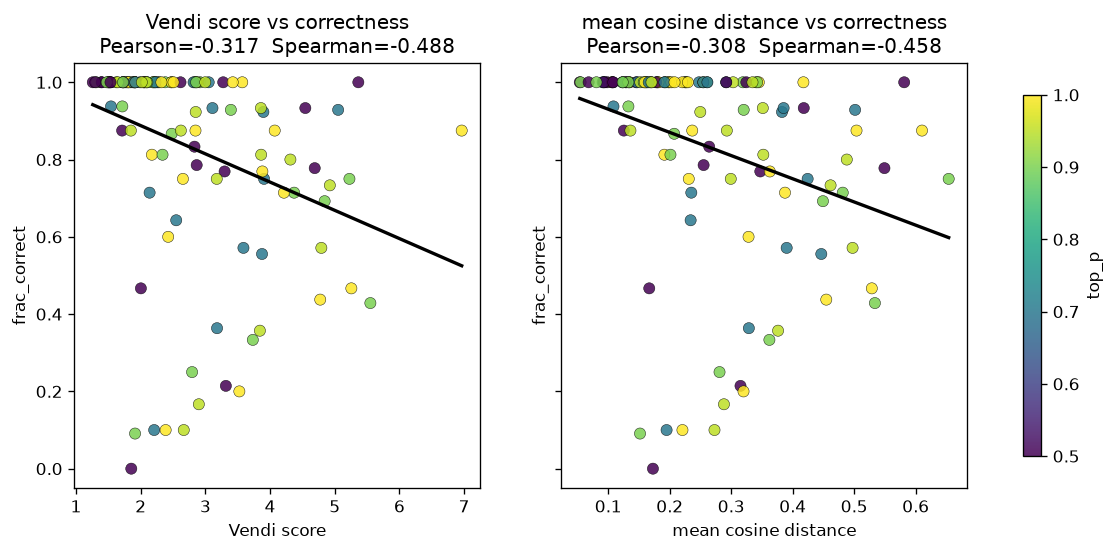

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for ax, col, name in [(axes[0],"vendi","Vendi score"), (axes[1],"cos","mean cosine distance")]:
    sc = ax.scatter(df[col], df.fc, c=df.top_p, cmap="viridis", s=45, edgecolor="k", linewidth=0.3, alpha=0.85)
    x, y = df[col].to_numpy(float), df.fc.to_numpy(float)
    m = ~(np.isnan(x)|np.isnan(y)); x,y=x[m],y[m]
    b,a = np.polyfit(x,y,1); xs=np.linspace(x.min(),x.max(),50); ax.plot(xs, a+b*xs, "k-", lw=2)
    p,s = corr(x,y)
    ax.set_title(f"{name} vs correctness\nPearson={p:+.3f}  Spearman={s:+.3f}")
    ax.set_xlabel(name); ax.set_ylabel("frac_correct")
fig.colorbar(sc, ax=axes, label="top_p", shrink=0.85); plt.show()

## Per-top_p — which top_p is optimal?

Harmonic mean H = 2·c·d/(c+d), with c=frac_correct and d=(vendi-1)/15 (normalized diversity).


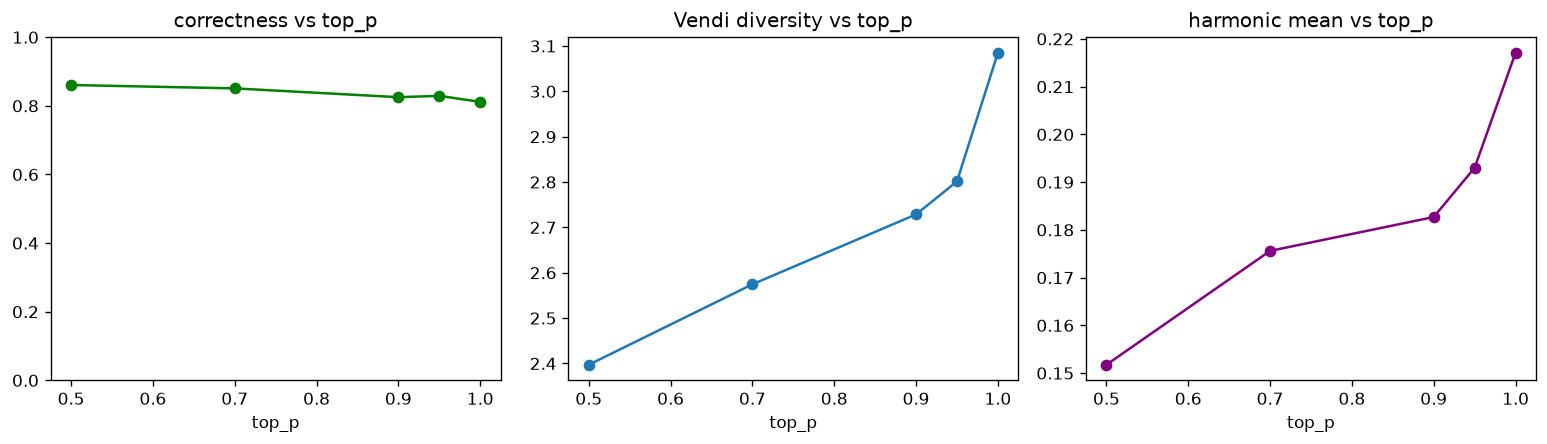

argmax correctness: 0.5 | argmax harmonic: 1.0


,top_p,correctness,vendi,harmonic
0,0.50,0.861,2.397,0.152
1,0.70,0.851,2.575,0.176
2,0.90,0.825,2.729,0.183
3,0.95,0.829,2.801,0.193
4,1.00,0.811,3.085,0.217


In [4]:
df["dnorm"] = (df.vendi - 1) / 15.0
df["harmonic"] = np.where(df.fc + df.dnorm == 0, 0.0, 2*df.fc*df.dnorm/(df.fc+df.dnorm))
g = df.groupby("top_p").agg(correctness=("fc","mean"), vendi=("vendi","mean"),
                            harmonic=("harmonic","mean")).reset_index()
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
ax[0].plot(g.top_p, g.correctness, "o-", color="green"); ax[0].set_title("correctness vs top_p"); ax[0].set_ylim(0,1)
ax[1].plot(g.top_p, g.vendi, "o-"); ax[1].set_title("Vendi diversity vs top_p")
ax[2].plot(g.top_p, g.harmonic, "o-", color="purple"); ax[2].set_title("harmonic mean vs top_p")
for a in ax: a.set_xlabel("top_p")
plt.tight_layout(); plt.show()
print("argmax correctness:", g.loc[g.correctness.idxmax(),"top_p"],
      "| argmax harmonic:", g.loc[g.harmonic.idxmax(),"top_p"])
g.round(3)

## Per-example breakdown (clean set)

Mean premise accuracy per question (over top_p), sorted. Low-accuracy = image-hallucination cases.


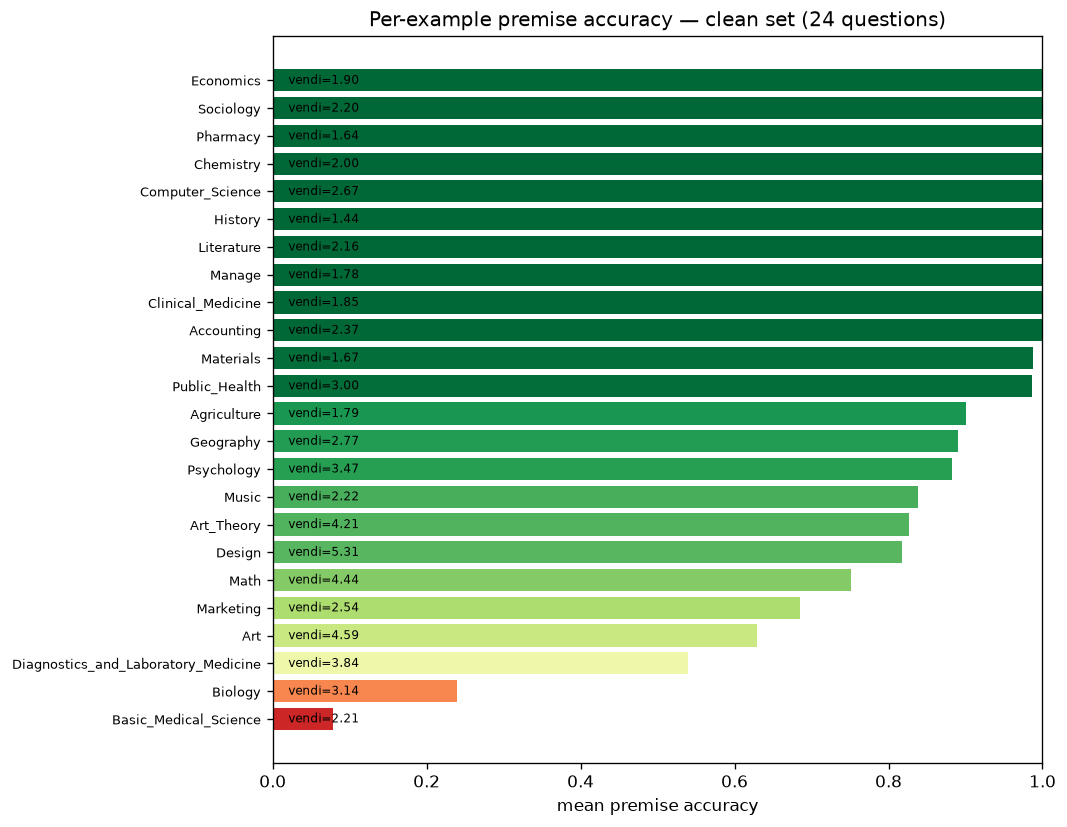

In [5]:
pe = df.groupby(["id","subject"]).agg(acc=("fc","mean"), vendi=("vendi","mean")).reset_index().sort_values("acc")
fig, ax = plt.subplots(figsize=(9, 7)); y = np.arange(len(pe))
ax.barh(y, pe.acc, color=plt.cm.RdYlGn(pe.acc))
ax.set_yticks(y); ax.set_yticklabels(pe.subject, fontsize=8)
ax.set_xlabel("mean premise accuracy"); ax.set_xlim(0,1); ax.set_title("Per-example premise accuracy — clean set (24 questions)")
for i,v in enumerate(pe.vendi): ax.text(0.01, i, f"  vendi={v:.2f}", va="center", fontsize=7)
plt.tight_layout(); plt.show()

---
### Takeaways (clean set — truncation removed everywhere; premise as the unit of analysis)
- **Diversity ↔ correctness is negative:** vendi~corr Pearson ≈ **−0.32** (Spearman −0.49), strengthening to **−0.56** when the 3 image-hallucination questions are dropped. The stronger −0.51 seen with truncated samples included was largely an artifact.
- **Correctness slightly *declines* with top_p** (best at low top_p ≈0.5–0.7, ~0.86 → 0.81 at 1.0). The harmonic optimum at top_p=1.0 is degenerate (just chasing diversity).
- **Practical pick: top_p ≈ 0.5–0.7** for correct premises; go higher only if you want premise diversity for ensembling.
- Both the diversity embedding and the correctness judge operate on the **extracted premise** (the `Premise:` line), not the `<think>` trace.
- Edit `DROP` to toggle the 3 outlier questions.